In [6]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report


In [27]:
data_path = r"C:\Users\offic\Desktop\Baby Cry's Reason\Dataset"

In [28]:
from pydub import AudioSegment
import os

def ensure_wav(file_path):
    """
    Agar file .wav nahi hai (.m4a / .3gp / .mp3 etc.),
    to ye automatically usi jagah temporary .wav bana dega.
    """
    if not file_path.lower().endswith(".wav"):
        temp_wav = file_path + "_temp.wav"
        try:
            sound = AudioSegment.from_file(file_path)
            sound.export(temp_wav, format="wav")
            return temp_wav
        except Exception as e:
            print(f"❌ Conversion failed for {file_path}: {e}")
            return None
    return file_path


In [29]:
def extract_features(folder_path):
    features = []
    labels = []
    for label_name in os.listdir(folder_path):
        label_folder = os.path.join(folder_path, label_name)
        if not os.path.isdir(label_folder):
            continue
        for file_name in os.listdir(label_folder):
            file_path = os.path.join(label_folder, file_name)
            
            # 🔹 Convert to wav if needed
            converted_path = ensure_wav(file_path)
            if converted_path is None:
                continue

            try:
                audio, sr = librosa.load(converted_path, duration=3, offset=0.5)
                mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)
                features.append(mfcc)
                labels.append(label_name)
            except Exception as e:
                print(f"❌ Error with file {file_name}: {e}")
    return np.array(features), np.array(labels)


In [30]:
X, y = extract_features(data_path)
print("✅ Feature extraction complete!")
print("Feature shape:", X.shape)
print("Unique labels:", np.unique(y))


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\pydub\utils.py:198: RuntimeWarning: Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work
  warn("Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work", RuntimeWarning)


❌ Conversion failed for C:\Users\offic\Desktop\Baby Cry's Reason\Dataset\Hungry\Lapar AUD-20150509-WA0001.m4a: [WinError 2] The system cannot find the file specified
❌ Conversion failed for C:\Users\offic\Desktop\Baby Cry's Reason\Dataset\Hungry\record-baby-1 cari puting.3gp: [WinError 2] The system cannot find the file specified
❌ Conversion failed for C:\Users\offic\Desktop\Baby Cry's Reason\Dataset\Hungry\record-baby2 puting dilepas.3gp: [WinError 2] The system cannot find the file specified
❌ Conversion failed for C:\Users\offic\Desktop\Baby Cry's Reason\Dataset\Uncomfortable\Minta Gendong AUD-20150509-WA0000.m4a: [WinError 2] The system cannot find the file specified
❌ Conversion failed for C:\Users\offic\Desktop\Baby Cry's Reason\Dataset\Uncomfortable\recordgntipopok.3gp: [WinError 2] The system cannot find the file specified
✅ Feature extraction complete!
Feature shape: (61, 40)
Unique labels: ['Hungry' 'Tired' 'Uncomfortable']


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode text labels (Hungry, Tired, Uncomfortable) into numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Label classes:", le.classes_)


Training samples: 48
Testing samples: 13
Label classes: ['Hungry' 'Tired' 'Uncomfortable']


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(40,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes: Hungry, Tired, Uncomfortable
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))


Epoch 1/50


C:\Users\offic\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.1406 - loss: 30.0390 - val_accuracy: 0.5385 - val_loss: 7.7649
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3307 - loss: 18.7396 - val_accuracy: 0.5385 - val_loss: 7.9077
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4844 - loss: 12.0492 - val_accuracy: 0.4615 - val_loss: 9.7857
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5417 - loss: 13.5665 - val_accuracy: 0.6154 - val_loss: 7.7236
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5104 - loss: 10.3249 - val_accuracy: 0.4615 - val_loss: 12.0924
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4479 - loss: 18.4652 - val_accuracy: 0.4615 - val_loss: 11.3825
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5026 - loss: 10.9376 - val_accuracy: 0.7692 - val_loss: 6.8475
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5677 - loss: 10.7842 - val_accuracy: 0.5385 - val_loss: 7.1105


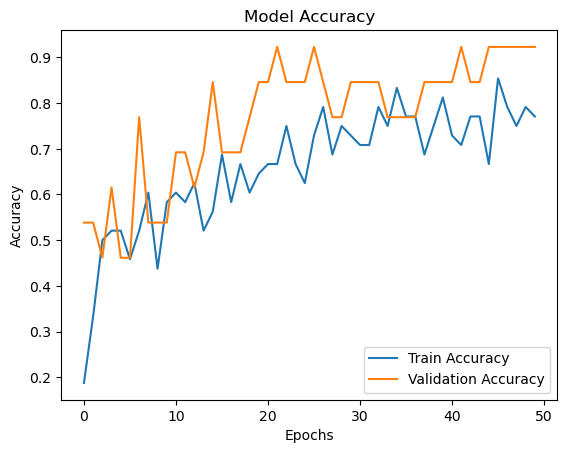

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


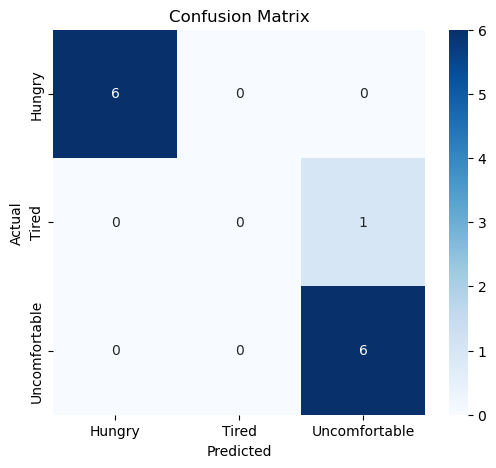

               precision    recall  f1-score   support

       Hungry       1.00      1.00      1.00         6
        Tired       0.00      0.00      0.00         1
Uncomfortable       0.86      1.00      0.92         6

     accuracy                           0.92        13
    macro avg       0.62      0.67      0.64        13
 weighted avg       0.86      0.92      0.89        13



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Accuracy curve
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

from sklearn.utils.multiclass import unique_labels

labels_present = unique_labels(y_true_classes, y_pred_classes)
print(classification_report(y_true_classes, y_pred_classes,
                            labels=labels_present,
                            target_names=le.inverse_transform(labels_present)))



In [48]:
import numpy as np
from pydub import AudioSegment
import librosa

def ensure_wav(file_path):
    """
    Agar file .wav nahi hai (.m4a / .3gp / .mp3 etc.)
    to automatic usi jagah temporary .wav bana dega.
    """
    if not file_path.lower().endswith(".wav"):
        temp_wav = file_path + "_temp.wav"
        try:
            sound = AudioSegment.from_file(file_path)
            sound.export(temp_wav, format="wav")
            return temp_wav
        except Exception as e:
            print(f"❌ Conversion failed for {file_path}: {e}")
            return None
    return file_path


def predict_cry_reason(model, file_path, label_encoder):
    # Ensure file is wav format
    file_path = ensure_wav(file_path)
    if file_path is None:
        print("❌ Audio conversion failed. Skipping file.")
        return

    try:
        audio, sr = librosa.load(file_path, duration=3, offset=0.5)
        mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)
        mfcc = np.expand_dims(mfcc, axis=0)

        prediction = model.predict(mfcc)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)

        print(f"Predicted Reason: {label_encoder.classes_[predicted_class]}")
        print(f"Confidence: {confidence*100:.2f}%")

    except Exception as e:
        print(f"Error while processing file: {e}")


In [49]:
file_path = r"C:\Users\offic\Downloads\265792145-baby-unhappy-crying-sad-tired-.wav"  
predict_cry_reason(model, file_path, le)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Reason: Tired
Confidence: 77.52%


In [38]:
model.save("baby_cry_reason_model.h5")

import joblib
joblib.dump(le, "label_encoder.pkl")

print("✅ Model & label encoder saved successfully!")


✅ Model & label encoder saved successfully!


In [42]:
from sklearn.preprocessing import LabelEncoder
import joblib

le = LabelEncoder()
le.fit(["Hungry", "Tired", "Uncomfortable"])        
joblib.dump(le, "label_encoder.pkl")
print("✅ label_encoder.pkl created with labels:", le.classes_)


✅ label_encoder.pkl created with labels: ['Hungry' 'Tired' 'Uncomfortable']
